In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns",None)

plt.style.use("ggplot")

In [2]:
credit_df = pd.read_csv("../data/processed/credit_cleaned.csv")

credit_df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,Unknown,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,Unknown,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
credit_df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

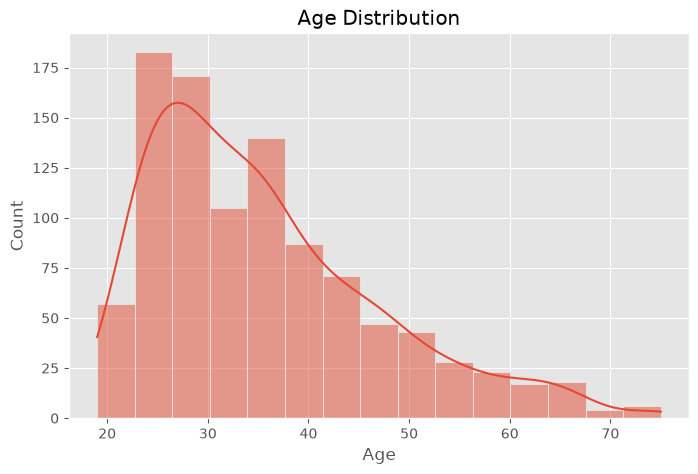

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=credit_df,
    x="Age",
    bins=15,
    kde=True
)

plt.title("Age Distribution")

plt.show()

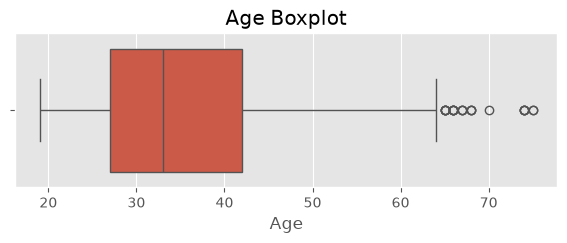

In [5]:
plt.figure(figsize=(7,2))

sns.boxplot(
    x=credit_df["Age"]
)

plt.title("Age Boxplot")

plt.show()

In [6]:

credit_df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

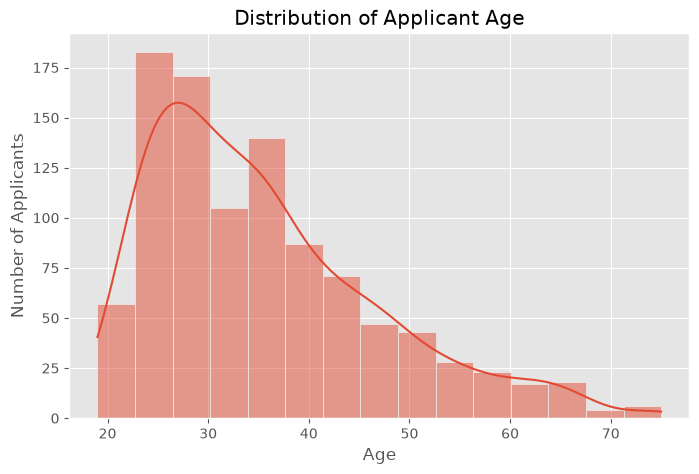

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=credit_df,
    x="Age",
    bins=15,
    kde=True
)

plt.title("Distribution of Applicant Age")
plt.xlabel("Age")
plt.ylabel("Number of Applicants")

plt.show()

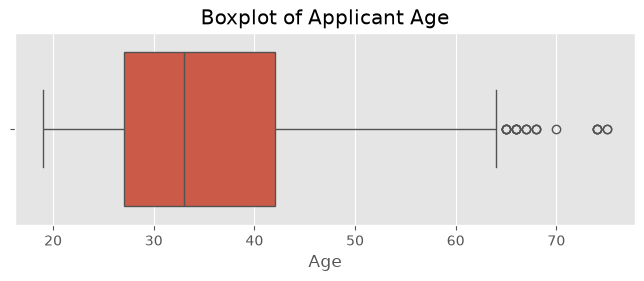

In [8]:
plt.figure(figsize=(8,2.5))

sns.boxplot(x=credit_df["Age"])

plt.title("Boxplot of Applicant Age")

plt.show()

## Age Analysis


- The average applicant age is approximately 35.5 years
- The median age is **33 years**, indicating a slight positive skew.
- The majority of applicants fall between 27 and 42 years.
- No missing values are present in the Age feature.
- A few older applicants (above 65 years) appear as outliers in the boxplot, but these represent valid customer records and will be retained.

# Business Insight
The bank primarily serves working-age customers. The age distribution is slightly right-skewed because a small number of older applicants increase the average age. Age may influence repayment behavior, which will be investigated later using the **Risk** variable.

In [9]:
credit_df["Credit amount"].describe()

count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: Credit amount, dtype: float64

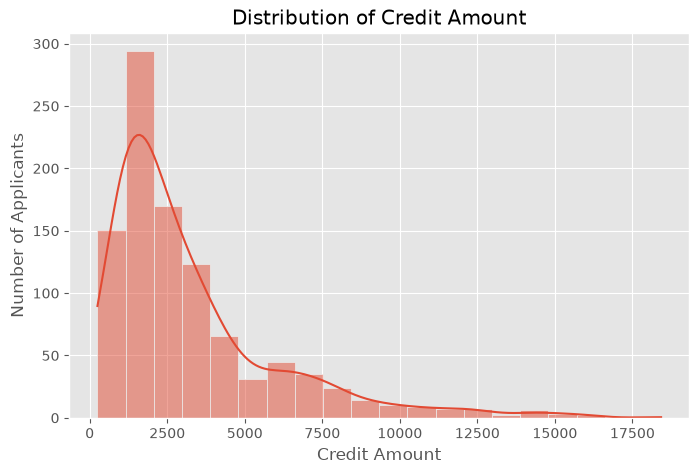

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=credit_df,
    x="Credit amount",
    bins=20,
    kde=True
)

plt.title("Distribution of Credit Amount")
plt.xlabel("Credit Amount")
plt.ylabel("Number of Applicants")

plt.show()

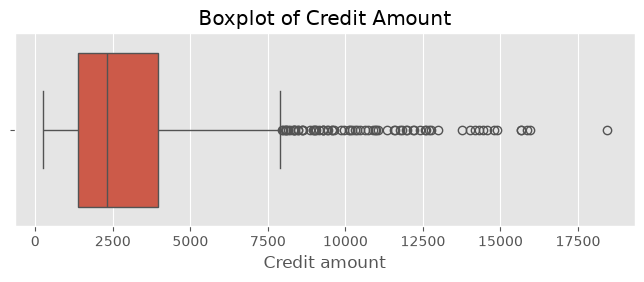

In [11]:
plt.figure(figsize=(8,2.5))

sns.boxplot(x=credit_df["Credit amount"])

plt.title("Boxplot of Credit Amount")

plt.show()

In [12]:
credit_df["Credit amount"].skew()

np.float64(1.9496276798326209)

# Credit Amount Analysis
- The average credit amount is **3271.26**.
- The median credit amount is **2319.50**, which is lower than the mean.
- Credit amounts range from **250** to **18424**.
- The feature has a skewness of approximately **1.95**, indicating a highly right-skewed distribution.

# Distribution

- Most applicants request small to medium-sized loans.
- A small number of applicants request very large loans, creating a long right tail.
- Several high-value loans appear as outliers in the boxplot but represent valid customer records.

### Business Insight

The bank primarily issues small and medium-sized loans. A limited number of customers request significantly larger loans. The relationship between loan amount and credit risk will be examined later using the **Risk** variable.

In [13]:
credit_df["Duration"].describe()

count    1000.000000
mean       20.903000
std        12.058814
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max        72.000000
Name: Duration, dtype: float64

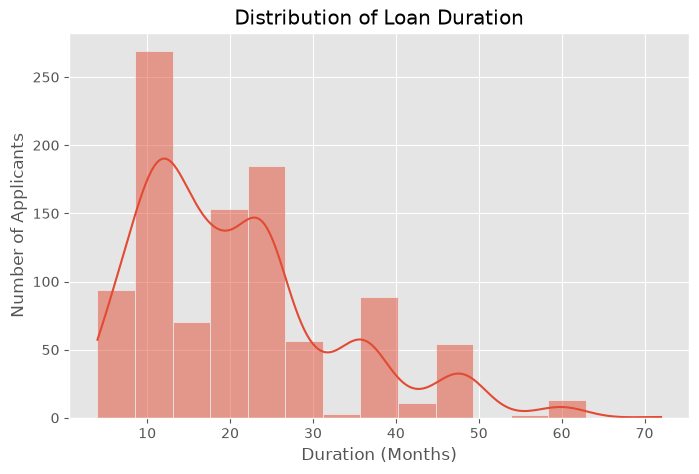

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=credit_df,
    x="Duration",
    bins=15,
    kde=True
)

plt.title("Distribution of Loan Duration")
plt.xlabel("Duration (Months)")
plt.ylabel("Number of Applicants")

plt.show()

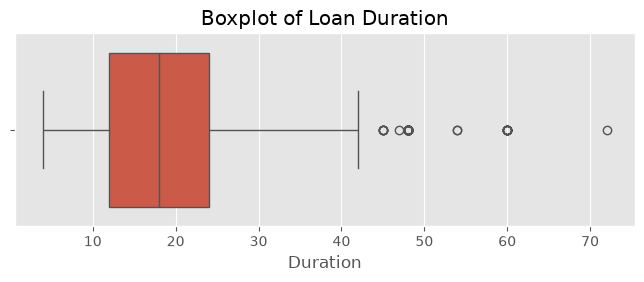

In [15]:
plt.figure(figsize=(8,2.5))

sns.boxplot(x=credit_df["Duration"])

plt.title("Boxplot of Loan Duration")

plt.show()

In [16]:
credit_df["Duration"].skew()

np.float64(1.0941841715555418)

## Duration Analysis

### Statistical Findings

- Average loan duration:
- Median loan duration:
- Minimum duration:
- Maximum duration:
- Skewness:

### Business Insight

Loan duration represents the repayment period of the loan. Longer repayment periods may expose the bank to higher uncertainty and potentially greater credit risk.


# Bivariate Analysis



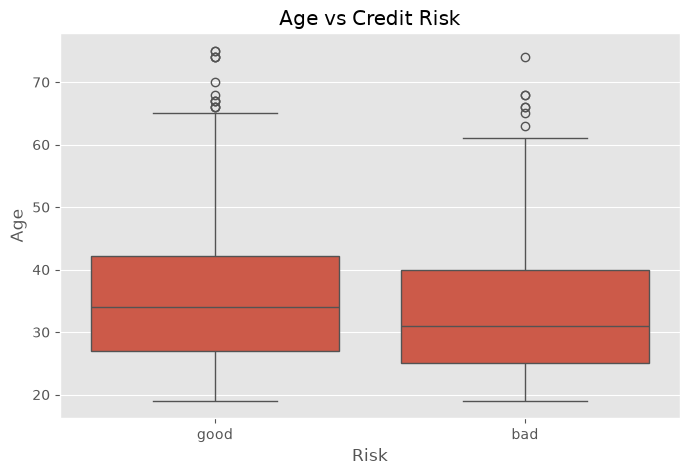

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=credit_df,
    x="Risk",
    y="Age"
)

plt.title("Age vs Credit Risk")
plt.xlabel("Risk")
plt.ylabel("Age")

plt.show()

# Credit Amount vs Risk

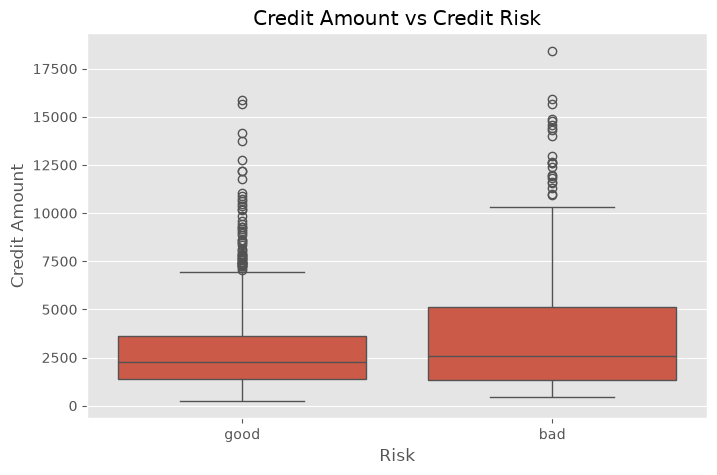

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=credit_df,
    x="Risk",
    y="Credit amount"
)

plt.title("Credit Amount vs Credit Risk")
plt.xlabel("Risk")
plt.ylabel("Credit Amount")

plt.show()

In [19]:
credit_df.groupby("Risk")["Credit amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Risk,,,,,,,,
bad,300.0,3938.126667,3535.818955,433.0,1352.5,2574.5,5141.50,18424.0
good,700.0,2985.457143,2401.472278,250.0,1375.5,2244.0,3634.75,15857.0


# Duration vs Risk

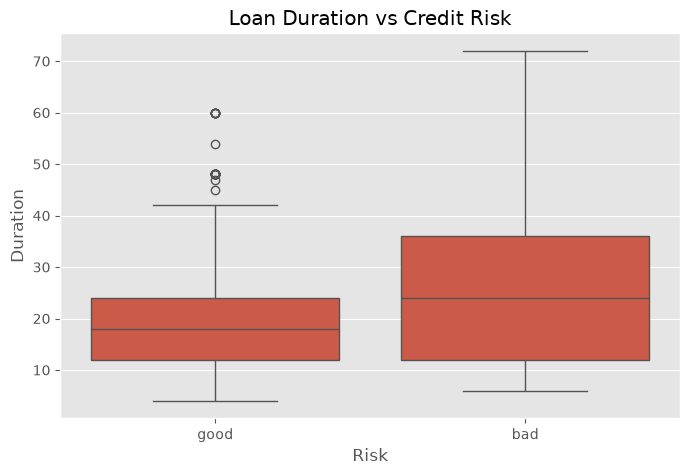

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=credit_df,
    x="Risk",
    y="Duration"
)

plt.title("Loan Duration vs Credit Risk")
plt.show()

In [23]:
credit_df.groupby("Risk")["Duration"].describe()

,count,mean,std,min,25%,50%,75%,max
Risk,,,,,,,,
bad,300.0,24.860000,13.282639,6.0,12.0,24.0,36.0,72.0
good,700.0,19.207143,11.079564,4.0,12.0,18.0,24.0,60.0


## Duration vs Credit Risk

### Observation

- Bad-risk customers have a higher average loan duration (24.86 months) than good-risk customers (19.21 months).
- The median loan duration is also higher for bad-risk customers.
- The distribution of loan duration is more spread out among bad-risk customers.
- The longest loan durations are observed in the bad-risk group.

### Business Insight

Customers with longer repayment periods tend to be associated with higher credit risk. Loan duration appears to be an important variable for credit risk assessment and should be included in predictive modeling.


# Sex vs Credit Risk

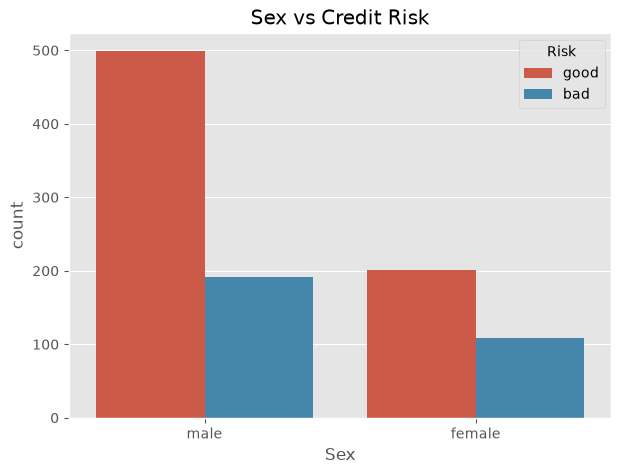

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=credit_df,
    x="Sex",
    hue="Risk"
)

plt.title("Sex vs Credit Risk")

plt.show()

# Housing vs Credit Risk

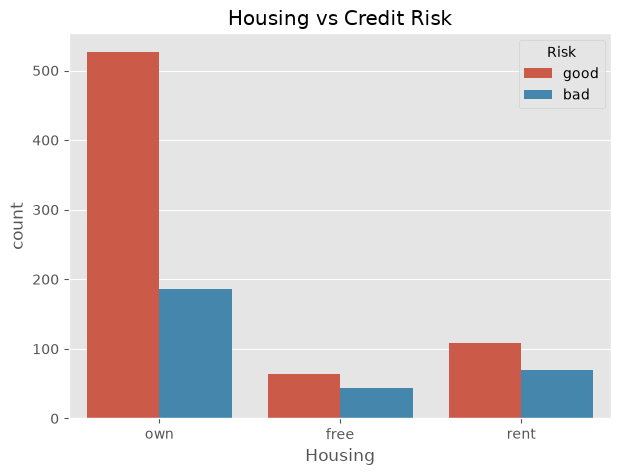

In [25]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=credit_df,
    x="Housing",
    hue="Risk"
)

plt.title("Housing vs Credit Risk")

plt.show()

# Saving Accounts vs Credit Risk

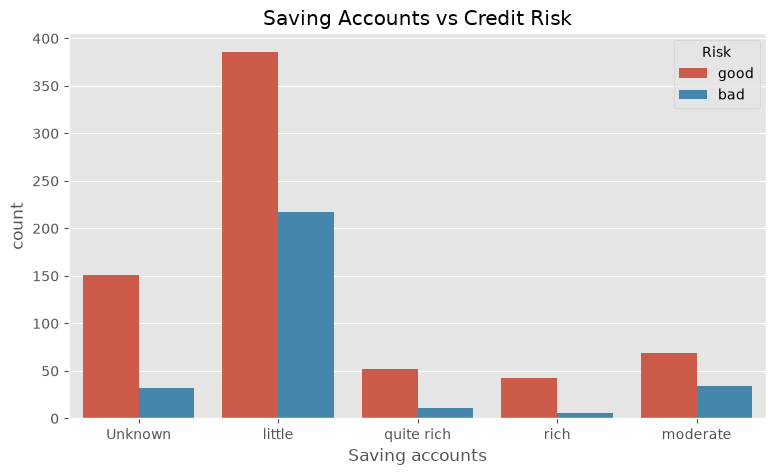

In [26]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=credit_df,
    x="Saving accounts",
    hue="Risk"
)

plt.title("Saving Accounts vs Credit Risk")

plt.show()

# Checking Account vs Credit Risk

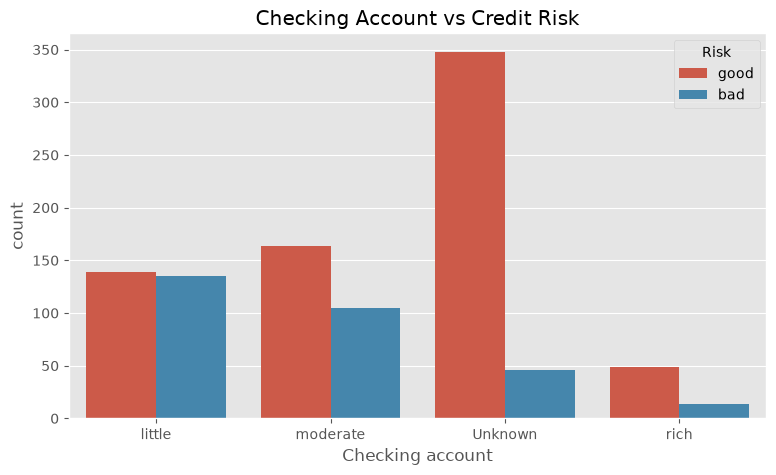

In [27]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=credit_df,
    x="Checking account",
    hue="Risk"
)

plt.title("Checking Account vs Credit Risk")

plt.show()

# Purpose vs Credit Risk

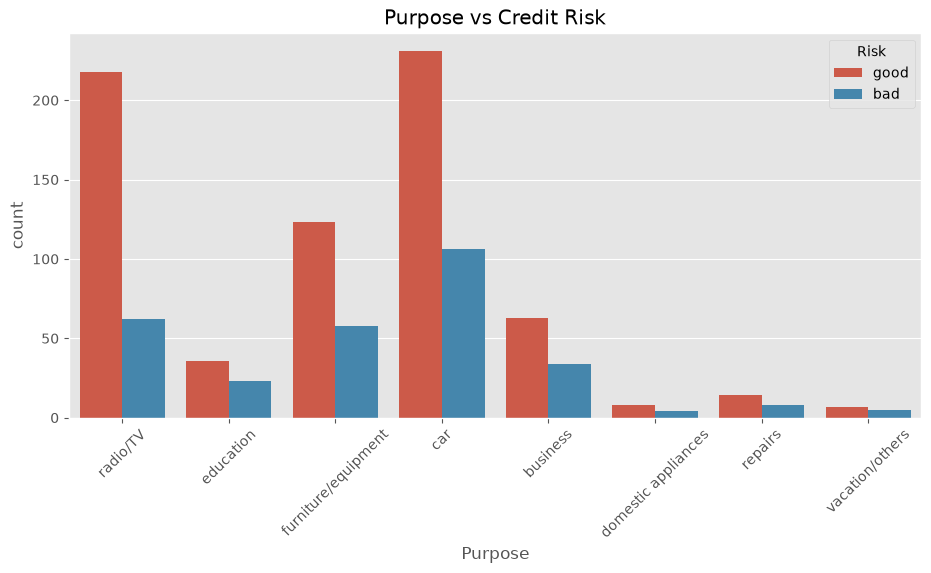

In [28]:
plt.figure(figsize=(11,5))

sns.countplot(
    data=credit_df,
    x="Purpose",
    hue="Risk"
)

plt.xticks(rotation=45)
plt.title("Purpose vs Credit Risk")

plt.show()

# Exploratory Data Analysis Summary

## Numerical Features

### Age
- Most applicants are between 27 and 42 years old.
- The age distribution is slightly right-skewed.
- Age alone does not strongly distinguish good-risk and bad-risk customers.

### Credit Amount
- Credit amount is highly right-skewed.
- Bad-risk customers tend to borrow larger amounts than good-risk customers.
- Credit amount appears to be an important predictor of credit risk.

### Duration
- Most loans have durations between 12 and 24 months.
- Bad-risk customers generally have longer loan durations.
- Duration appears to be one of the strongest indicators of credit risk.

## Categorical Features

- Most applicants are male.
- Most customers own their homes.
- The majority of customers have little savings.
- Car is the most common loan purpose.
- Categorical variables require statistical testing to confirm their relationship with credit risk.

## Key Findings

The features that appear most strongly associated with credit risk are:

- Credit Amount
- Duration

Age shows only a small difference between good-risk and bad-risk customers.

Categorical variables require hypothesis testing before drawing conclusions.